In [1]:
%reload_ext autoreload
%autoreload 2

import os
import pickle
import numpy as np
import json

from fpp.utils.validation import pp_finite_sample_band
from fpp.utils.posterior import multi_corner

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../src/fpp/utils/matplotlibrc")

# TMP

In [5]:
from fpp.models.np_model import NPModel
m = NPModel()
z = np.load(os.environ['MYSTORE'] + f"/fermi/fermi-prob-prog/outputs/production/simulations/smallprior-0Alm.npy")

No data provided. Using Fermi data.


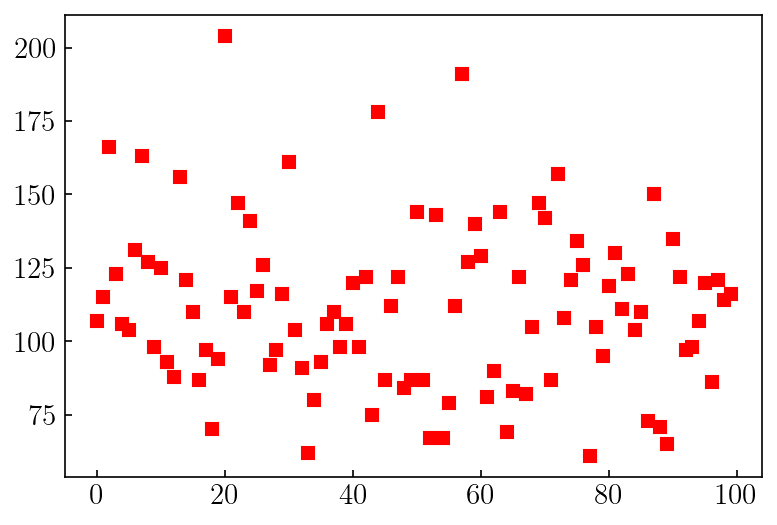

In [8]:
x = np.arange(100)
y = max_phot[:100]
plt.plot(x, y, 'rs')

In [6]:
max_phot = []
for i in range(100):
    data = z[i]
    max_phot.append(np.max(data[~m.mask_roi]))
    # print(f'{i}, {np.max(data[~m.mask_roi]):5.0f}, {np.max(data[~m.nm]):5.0f}, {np.max(data):5.0f}')

In [4]:
finished = [0, 1, 4, 6, 8, 9, 11, 12, 15, 16, 17, 18, 19, 21, 23, 25, 27, 28, 29]
full = np.arange(30)
','.join([str(i) for i in full if i not in finished])

'2,3,5,7,10,13,14,20,22,24,26'

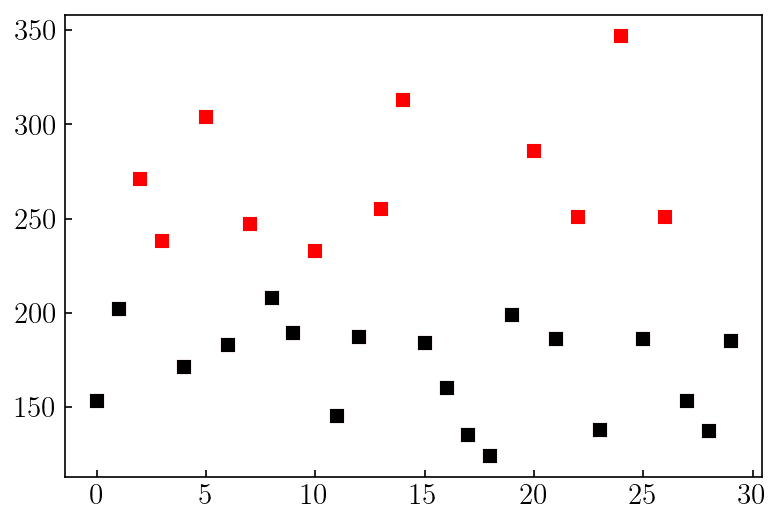

In [7]:
finished = [0, 1, 4, 6, 8, 9, 11, 12, 15, 16, 17, 18, 19, 21, 23, 25, 27, 28, 29]
x = np.arange(30)
y = max_phot[:30]
plt.plot(x, y, 'rs')
plt.plot([x[i] for i in finished], [y[i] for i in finished], 'ks')

# Coverage

In [2]:
run_name = 'calibration/svi-smallprior-0Alm-king'
z = pickle.load(open(os.environ['MYSTORE'] + f'/fermi/fermi-prob-prog/outputs/production/fits/{run_name}/p_nominal_actual_dict.p', 'rb'))
keys = list(z.keys())
keys.sort()
print(' '.join(keys))

C S_bub S_gce S_ics S_iso S_pib S_psc Sps_dsk Sps_gce f_bulge_poiss f_bulge_ps gamma_poiss gamma_ps lambdas_dsk lambdas_gce n1_dsk n1_gce n2_dsk n2_gce n3_dsk n3_gce sb1_dsk sb1_gce zs


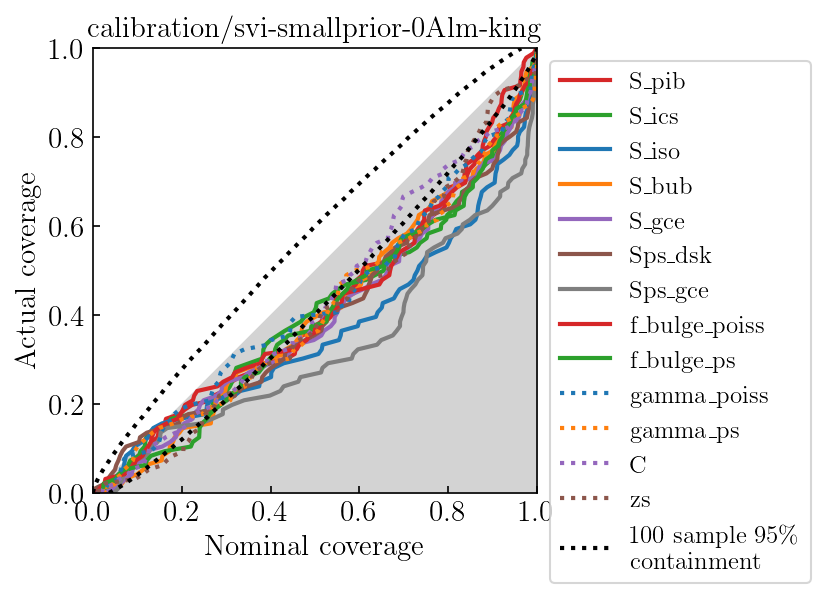

In [5]:
if 'pois' in run_name:
    labels = [
        'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
        'f_bulge_poiss', 'gamma_poiss',
    ]
else:
    labels = [
        'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
        'Sps_dsk', 'Sps_gce',
        'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
    ]

probs = [z[k] for k in labels]
ls_s = ['-'] * 9 + [':'] * 9

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
n_run = 100
lower, upper = pp_finite_sample_band(n_run)
ax.plot(upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage', title=run_name)

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()

# Corner

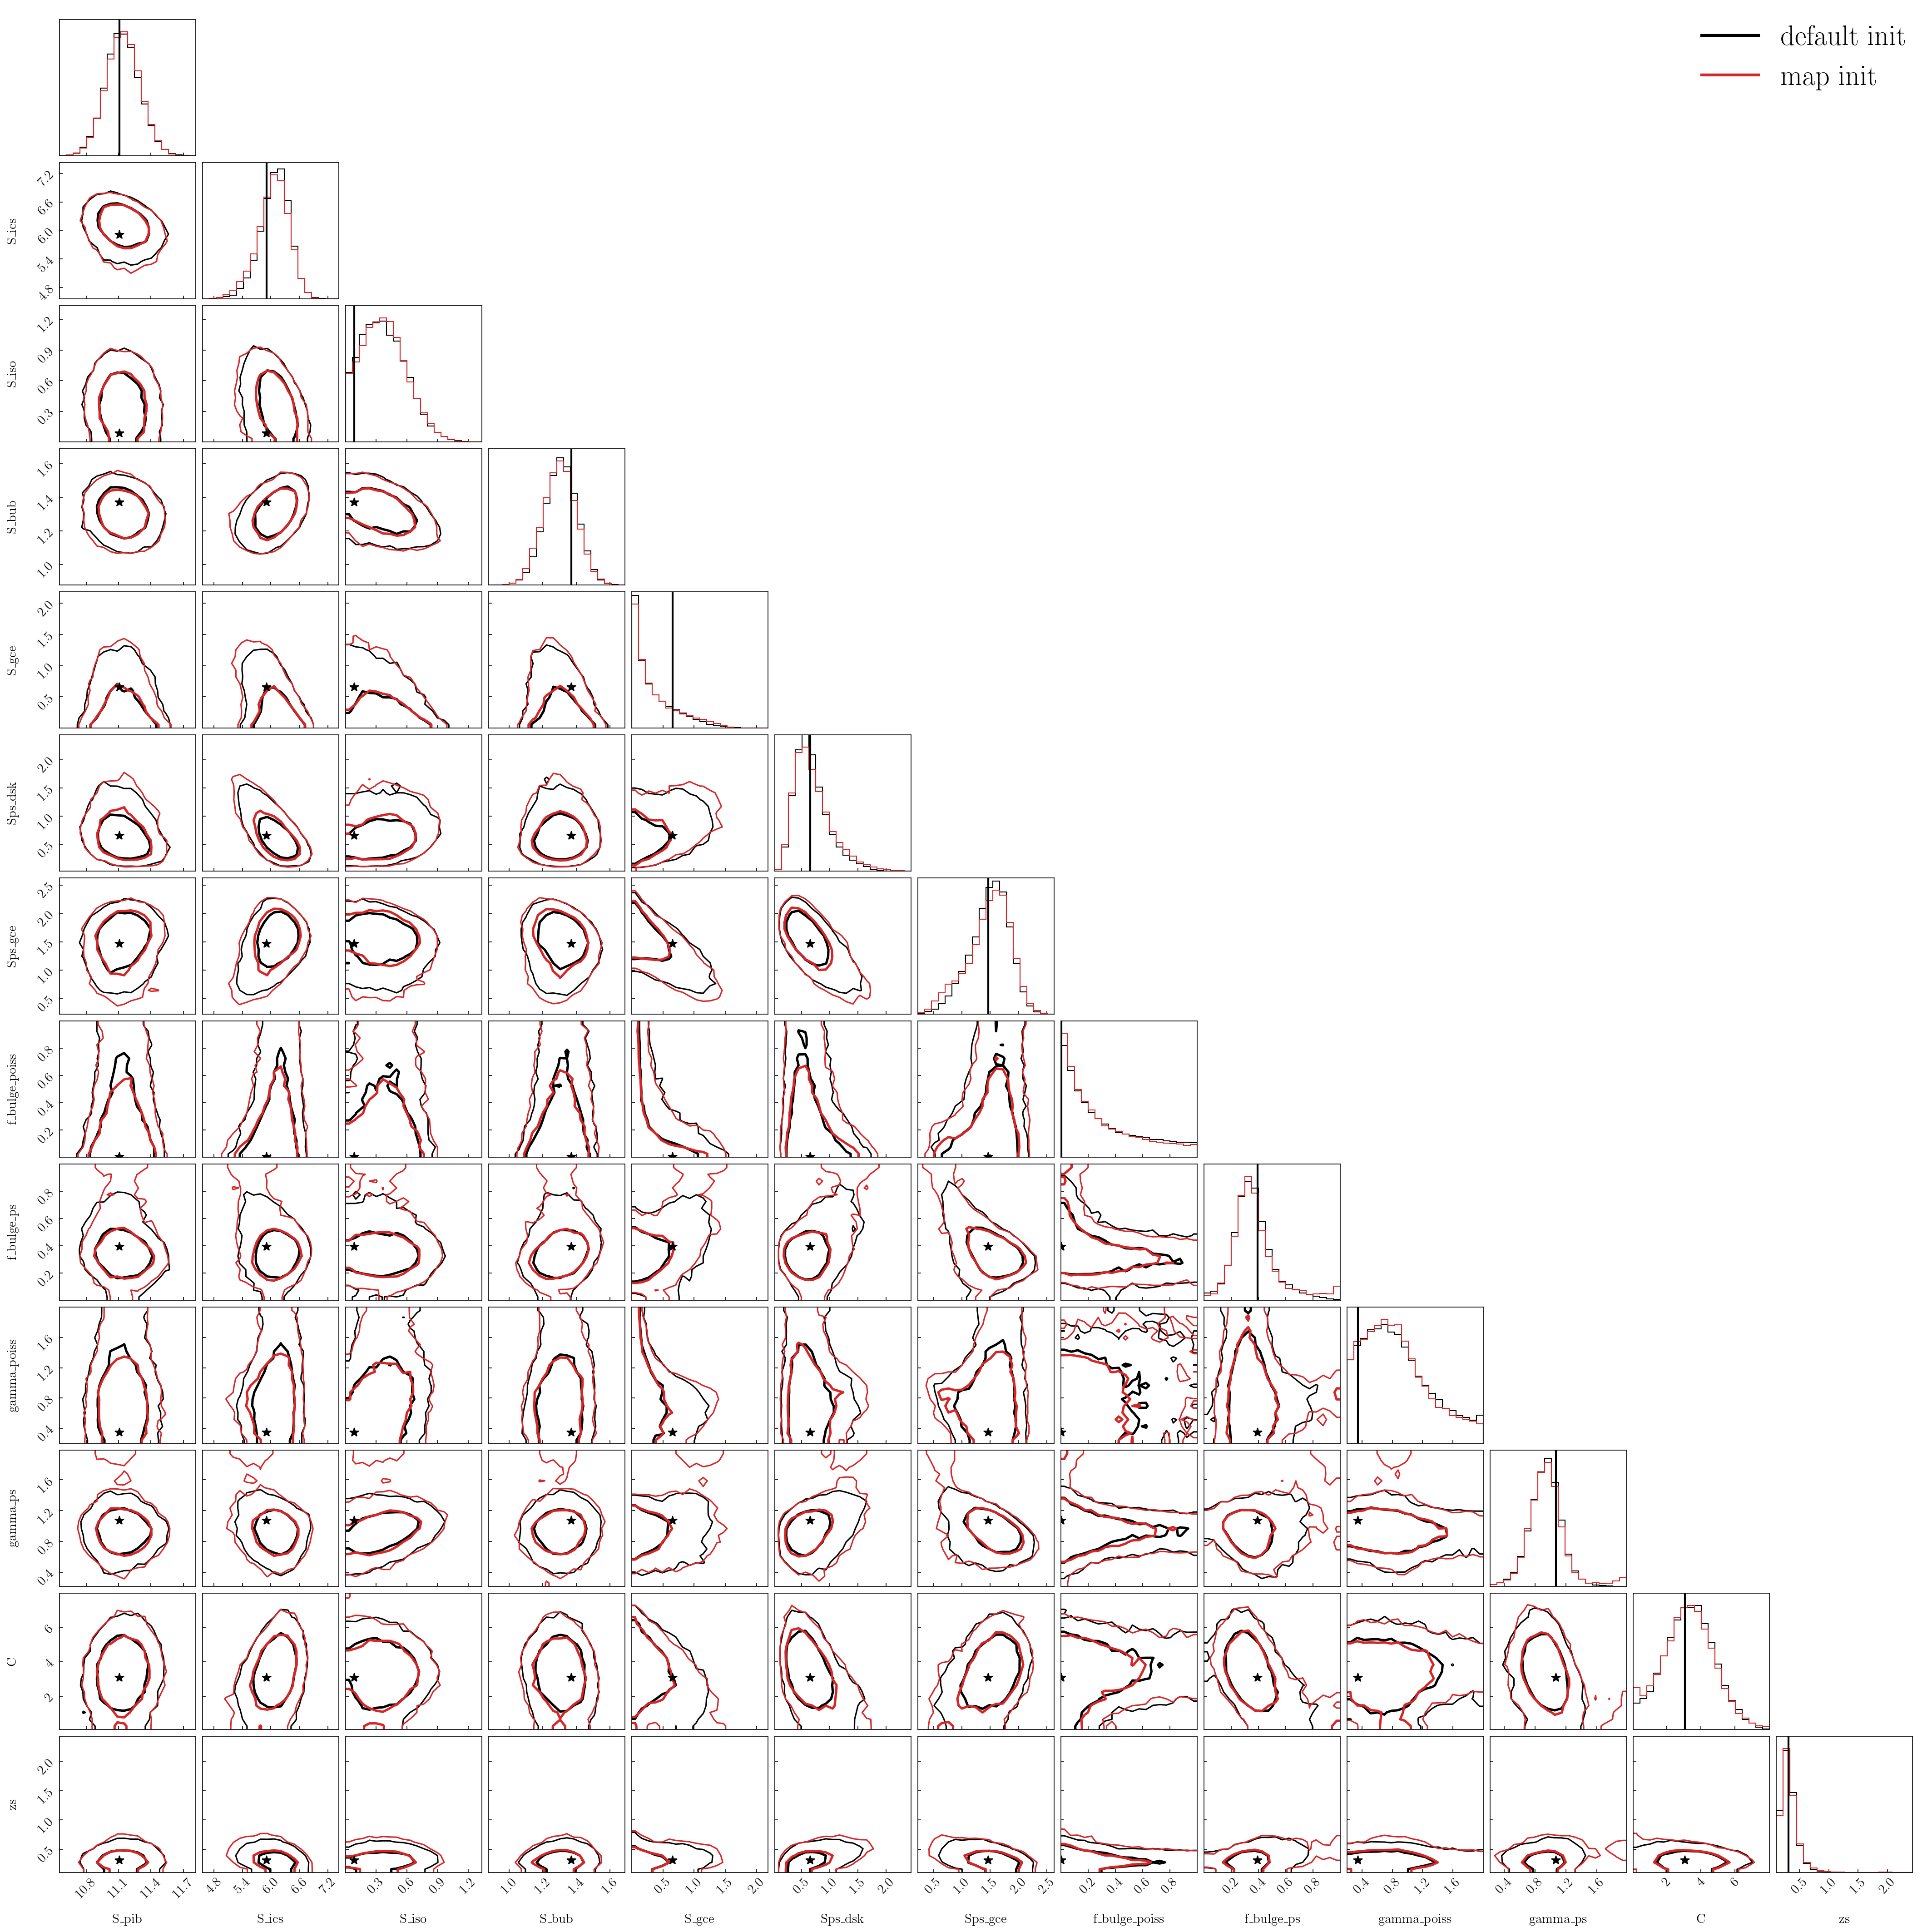

In [10]:
point_est = True
full_prior_i = None
# truth_fn = "../outputs/truths/truths_fullprior42-zeroAlm.json"
truth_fn = os.environ['MYSTORE'] + f'/fermi/fermi-prob-prog/outputs/production/fits/fermi/hmc-mapinit-init.json'

labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
fits_dir = os.environ['MYSTORE'] + f'/fermi/fermi-prob-prog/outputs/production/fits'
config_dict = {
    'default init' : (f'{fits_dir}/fermi/hmc.p', 'k'),
    'map init' : (f'{fits_dir}/fermi/hmc-mapinit.p', 'C0'),
}

#==============================================================================
s_in = {}
labels_dict = {}
colors_dict = {}
for key, (path, color) in config_dict.items():
    s = pickle.load(open(path, 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = key
    colors_dict[key] = color

if point_est:
    truth_dict = json.load(open(truth_fn, 'r'))
    if full_prior_i:
        truth_dict = truth_dict[full_prior_i]
    t_in = {k: truth_dict[k] for k in labels}
else:
    t_in = None

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, legend_dict=labels_dict)

In [3]:
from fpp.utils.posterior import dnds_posterior

In [6]:
def dnds_post_data():
    labels_func = lambda k: [f'Sps_{k}', f'n1_{k}', f'n2_{k}', f'n3_{k}', f'sb1_{k}', f'lambdas_{k}']
    samples_hmc = pickle.load(open(f'{fits_dir}/fermi/hmc.p', 'rb'))
    samples_svi = pickle.load(open(f'{fits_dir}/fermi/hmc-mapinit.p', 'rb'))
    dnds_d = {}
    dnds_d['gce-hmc'] = dnds_posterior(samples=samples_hmc, theta_keys=labels_func('gce'), plot=False)
    dnds_d['gce-svi'] = dnds_posterior(samples=samples_svi, theta_keys=labels_func('gce'), plot=False)
    dnds_d['dsk-hmc'] = dnds_posterior(samples=samples_hmc, theta_keys=labels_func('dsk'), plot=False)
    dnds_d['dsk-svi'] = dnds_posterior(samples=samples_svi, theta_keys=labels_func('dsk'), plot=False)
    return dnds_d

def plot_dnds_post(ax, dnds_d, k, xlabel=False, ylabel=False, title='', style='new'):
    s, dnds_med, dnds_68, dnds_95 = dnds_d[f'{k}-hmc']
    if style == 'new':
        color = 'gray'
        ax.plot(s, dnds_med, color=color, label=r'HMC')
        ax.plot(s, dnds_68[0], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_68[1], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_95[0], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.plot(s, dnds_95[1], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=0.2, fc='k', ec='none')
        # ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.2, fc='k', ec='none')
    else:
        ax.plot(s, dnds_med, color='k', label=r'HMC')
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=0.5, fc='C0', ec='none')
        ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.3, fc='C0', ec='none')
    s, dnds_med, dnds_68, dnds_95 = dnds_d[f'{k}-svi']
    if style == 'new':
        color = 'C0'
        ax.plot(s, dnds_med, color=color, label=r'HMC MAP init')
        ax.plot(s, dnds_68[0], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_68[1], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_95[0], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.plot(s, dnds_95[1], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=0.2, fc='C0', ec='none')
        # ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.2, fc='C0', ec='C0', ls='-')
    else:
        ax.plot(s, dnds_med, color='k', ls='--', label=r'HMC MAP init')
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=1.0, fc='none', ec='k', ls='--')
        ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.6, fc='none', ec='k', ls='--')
    ax.set(xlim=(1, 50), ylim=(1e-7, 1))
    ax.set(xscale='log', yscale='log')
    if xlabel:
        ax.set(xlabel='$S$ [counts]')
    if ylabel:
        ax.set(ylabel=r'$\mathrm{d}N/\mathrm{d}S$ [counts$^{-1}$]')
    ax.set(title=title)
    ax.legend(frameon=False)

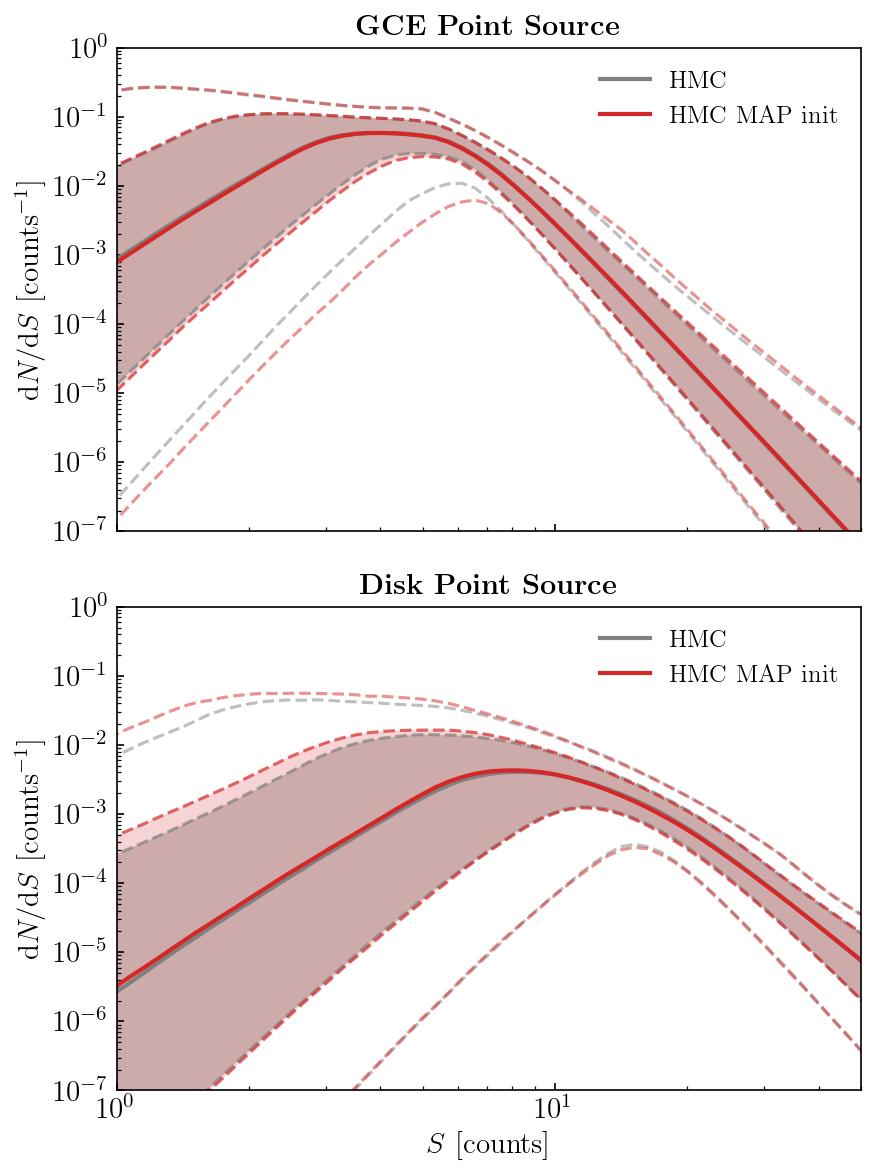

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

dnds_d = dnds_post_data()

plot_dnds_post(axs[0], dnds_d, 'gce', title=r'$\textbf{GCE Point Source}$', xlabel=False, ylabel=True)
plot_dnds_post(axs[1], dnds_d, 'dsk', title=r'$\textbf{Disk Point Source}$', xlabel=True, ylabel=True)

fig.tight_layout()